# **SIMULACIÓN CIRCUITO RC**

Es posible variar los valores de la Capacitancia, Resistencia y Voltaje Inicial, para analizar los diferentes comportamientos del circuito dado cada caso.

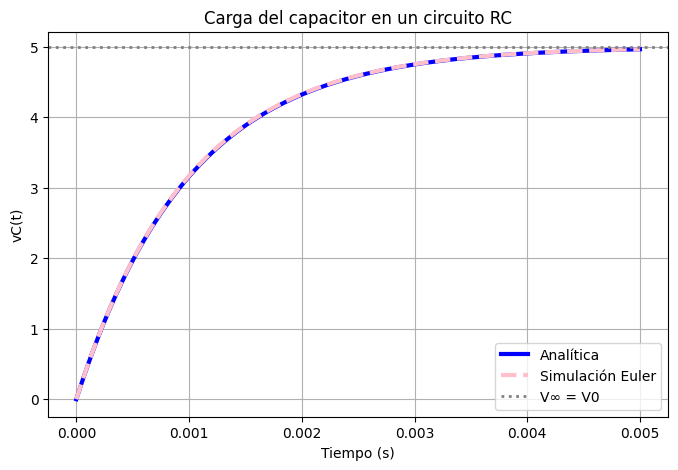

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# parámetros RC
R = 1000   # ohm
C = 1e-6   # farad
tau = R*C
V0 = 5

t = np.linspace(0, 5*tau, 500)
v_analitica = V0*(1 - np.exp(-t/tau))

# simulación numérica sencilla: método de Euler
dt = t[1]-t[0]
v_num = np.zeros_like(t)
for k in range(1, len(t)):
    dv = (V0 - v_num[k-1]) / tau
    v_num[k] = v_num[k-1] + dv*dt

plt.figure(figsize=(8,5))
plt.plot(t, v_analitica, color='blue', linewidth=3, label="Analítica")
plt.plot(t, v_num, '--', color='pink', linewidth=3, label="Simulación Euler")
plt.axhline(V0, linestyle=':', color='gray', linewidth=2, label="V∞ = V0")

plt.xlabel("Tiempo (s)")
plt.ylabel("vC(t)")
plt.title("Carga del capacitor en un circuito RC")
plt.legend()
plt.grid(True)
plt.show()


¿Qué demuestra este resultado?

 La curva azul = solución analítica

 Ambas coinciden casi perfectamente

→ Eso prueba que la solución analítica es correcta

→ Y que la simulación numérica reproduce el comportamiento físico del capacitor.

# **SIMULACIÓN CIRCUITO LC**


Es posible variar los valores de la Inductancia, Resistencia y Voltaje Inicial, para analizar los diferentes comportamientos del circuito dado cada caso.

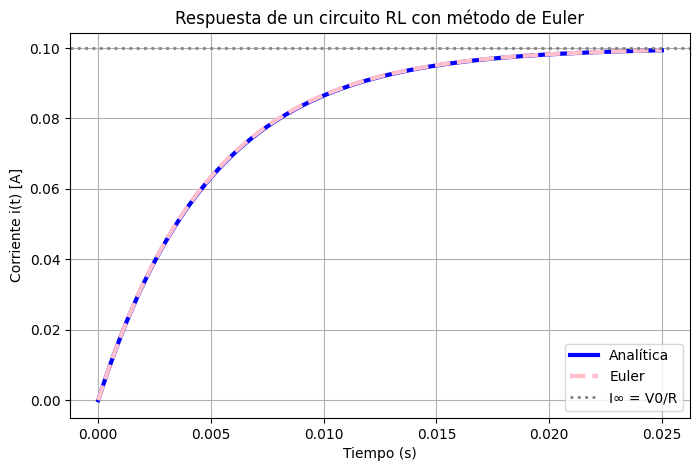

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros RL
R = 100      # ohm
L = 0.5      # henry
V0 = 10      # voltios

tau = L / R  # constante de tiempo

# Tiempo
t = np.linspace(0, 5 * tau, 500)
dt = t[1] - t[0]

# Solución analítica
i_analitica = (V0 / R) * (1 - np.exp(-t / tau))

# Simulación numérica: Euler
i_num = np.zeros_like(t)
for k in range(1, len(t)):
    didt = (V0 - R * i_num[k-1]) / L
    i_num[k] = i_num[k-1] + didt * dt

# Gráfica
plt.figure(figsize=(8,5))

plt.plot(t, i_analitica, color='blue', linewidth=3, label="Analítica")
plt.plot(t, i_num, '--', color='pink', linewidth=3, label="Euler")
plt.axhline(V0/R, linestyle=':', color='gray', linewidth=2, label="I∞ = V0/R")

plt.xlabel("Tiempo (s)")
plt.ylabel("Corriente i(t) [A]")
plt.title("Respuesta de un circuito RL con método de Euler")
plt.grid(True)
plt.legend()
plt.show()

# **SIMULACIÓN CIRCUITO RLC**

Es posible variar los valores de la Capacitancia, Resistencia, Inductancia y Voltaje Inicial, para analizar los diferentes comportamientos del circuito dado cada caso. Recordando que dependiendo del valor de la resistencia, difiere el amortiguamiento del circuito.

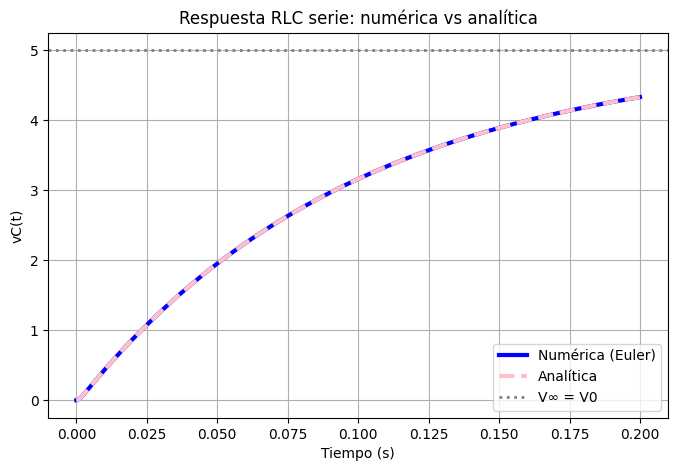

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- PARÁMETROS ----------
R = 100     # ohms  -> cambia esto para ver los 3 casos
L = 0.1      # henry
C = 1e-3     # farad
V0 = 5       # voltios

alpha = R/(2*L)
omega0 = 1/np.sqrt(L*C)

# ---------- TIEMPO ----------
t = np.linspace(0, 0.2, 5000)
dt = t[1] - t[0]

# ---------- NUMÉRICA (Euler) ----------
x1 = np.zeros_like(t)   # vC
x2 = np.zeros_like(t)   # dvC/dt

for k in range(len(t)-1):
    dx1 = x2[k]
    dx2 = (V0 - x1[k] - R*C*x2[k]) / (L*C)
    x1[k+1] = x1[k] + dx1*dt
    x2[k+1] = x2[k] + dx2*dt

# ---------- ANALÍTICA ----------
v_an = np.zeros_like(t)

# ---- Subamortiguado ----
if alpha < omega0:
    omega_d = np.sqrt(omega0**2 - alpha**2)
    A = -V0
    B = -(alpha/omega_d)*V0
    v_an = V0 + np.exp(-alpha*t)*(A*np.cos(omega_d*t) + B*np.sin(omega_d*t))

# ---- Crítico ----
elif np.isclose(alpha, omega0):
    A = -V0
    B = alpha*V0
    v_an = V0 + (A + B*t)*np.exp(-alpha*t)

# ---- Sobreamortiguado ----
else:
    s1 = -alpha + np.sqrt(alpha**2 - omega0**2)
    s2 = -alpha - np.sqrt(alpha**2 - omega0**2)

    # Resolver sistema:
    # A + B = -V0
    # A*s1 + B*s2 = 0
    A = -V0 * s2/(s2 - s1)
    B =  V0 * s1/(s2 - s1)

    v_an = V0 + A*np.exp(s1*t) + B*np.exp(s2*t)

# ---------- PLOT ----------
plt.figure(figsize=(8,5))
plt.plot(t, x1, label="Numérica (Euler)", linewidth=3, color='blue')
plt.plot(t, v_an, '--', label="Analítica", linewidth=3, color='pink')
plt.axhline(V0, linestyle=':', linewidth=2, color='gray', label="V∞ = V0")

plt.grid(True)
plt.xlabel("Tiempo (s)")
plt.ylabel("vC(t)")
plt.title("Respuesta RLC serie: numérica vs analítica")
plt.legend()
plt.show()




### **VALORES DE PRUEBA SUGERIDOS PARA ANALIZAR EL COMPORTAMIENTO:**

SUBAMORTIGUAMIENTO: R = 1, L = 0.1, C = 1e-3

CRITICAMENTE AMORTIGUADO: R = 20, L = 0.1, C = 1e-3

SOBREAMORTIGUADO: R = 100, L = 0.1, C = 1e-3
